In [1]:
# Kaggle setup
import os
import sys
import subprocess
import importlib
from pathlib import Path

IN_KAGGLE = os.path.exists("/kaggle")

def pip_install_safe(*packages):
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + list(packages)
    print("Installing:", " ".join(packages))
    subprocess.check_call(cmd)

# FIX: thêm adapters library (adapter-transformers)
required = {
    "transformers": "transformers",
    "datasets":     "datasets",
    "evaluate":     "evaluate",
    "accelerate":   "accelerate",
    "adapters":     "adapters",
}

for module_name, install_name in required.items():
    try:
        importlib.import_module(module_name)
        print(f"{module_name} already installed")
    except Exception:
        pip_install_safe("-U", install_name)

WORK_DIR = Path("/kaggle/working" if IN_KAGGLE else ".").resolve()
WORK_DIR.mkdir(parents=True, exist_ok=True)
print("Work directory:", WORK_DIR)

try:
    import torch
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    else:
        print("Running on CPU")
except Exception as e:
    print("Could not inspect torch device:", e)

HF_TOKEN = None
if IN_KAGGLE:
    try:
        from kaggle_secrets import UserSecretsClient
        HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        HF_TOKEN = None

if HF_TOKEN:
    try:
        from huggingface_hub import login
        login(HF_TOKEN, add_to_git_credential=False)
        print("Hugging Face login successful")
    except Exception as e:
        print("Hugging Face login skipped:", e)
else:
    print("HF_TOKEN not found. Hub upload will be skipped unless you login manually.")


transformers already installed
datasets already installed


2026-04-28 12:04:58.547679: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777377898.770371     173 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777377898.838138     173 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777377899.395164     173 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777377899.395212     173 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777377899.395215     173 computation_placer.cc:177] computation placer alr

evaluate already installed
accelerate already installed
adapters already installed
Work directory: /kaggle/working
GPU: Tesla T4
HF_TOKEN not found. Hub upload will be skipped unless you login manually.


## import thư viện

In [2]:
!pip uninstall -y adapters adapter-transformers huggingface_hub transformers

Found existing installation: adapters 0.2.1
Uninstalling adapters-0.2.1:
  Successfully uninstalled adapters-0.2.1
Found existing installation: huggingface-hub 0.23.5
Uninstalling huggingface-hub-0.23.5:
  Successfully uninstalled huggingface-hub-0.23.5
Found existing installation: transformers 4.39.3
Uninstalling transformers-4.39.3:
  Successfully uninstalled transformers-4.39.3


In [3]:
!pip uninstall -y peft sentence-transformers diffusers gradio huggingface_hub transformers

In [4]:
!pip install -q \
    transformers==4.39.3 \
    huggingface_hub==0.23.5 \
    adapters==0.2.1 \
    datasets \
    evaluate \
    accelerate \
    scikit-learn

In [5]:
import os
import time

import torch
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.utils.data import DataLoader

# FIX: dùng adapters library (adapter-transformers) thay vì peft
import adapters
from adapters import AutoAdapterModel, AdapterConfig

import evaluate
from transformers import (
    AutoTokenizer,
    get_linear_schedule_with_warmup,
    set_seed,
)
from tqdm import tqdm

set_seed(42)


## khai báo tham số cấu hình

In [ ]:
batch_size = 8
model_name_or_path = "bert-base-uncased"
task = "imdb_sentiment"
peft_type = "ADAPTER"
device = "cuda" if torch.cuda.is_available() else "cpu"
num_epochs = 10
output_dir = os.path.join(str(WORK_DIR), "peft_outputs")
os.makedirs(output_dir, exist_ok=True)


## Cấu hình Bottleneck Adapter và learning rate

In [7]:
# FIX: AdapterConfig đúng nghĩa — Bottleneck Adapter kiến trúc Pfeiffer 2020
# Cấu trúc: hidden(768) → down(48) → ReLU → up(768) + residual connection
# Chèn sau FFN mỗi transformer layer (12 layers × 1 adapter)
# Khác hoàn toàn LoRA: LoRA inject vào weight matrix, Adapter thêm module độc lập

adapter_name   = "bottleneck_adapter"
adapter_config = AdapterConfig.load(
    "pfeiffer",          # kiến trúc Pfeiffer: nhẹ hơn Houlsby, phổ biến hơn
    reduction_factor=16  # bottleneck_dim = 768 / 16 = 48
)
lr = 1e-4


## chuẩn bị dữ liệu

In [8]:
if any(k in model_name_or_path for k in ("gpt", "opt", "bloom")):
    padding_side = "left"
else:
    padding_side = "right"

tokenizer = AutoTokenizer.from_pretrained(model_name_or_path, padding_side=padding_side)
if getattr(tokenizer, "pad_token_id") is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from torch.utils.data import DataLoader

# ===== 1. Đọc dataset CSV =====
df = pd.read_csv("/kaggle/input/datasets/bohong111/datasets-imdb/IMDB Dataset.csv")

# ===== 2. Kiểm tra dữ liệu =====
print(df.columns)
print(df.head())

# ===== 3. Đổi tên cột =====
df = df.rename(columns={"review": "text", "sentiment": "label"})

# ===== 4. Convert label =====
df["label"] = df["label"].map({"positive": 1, "negative": 0})

# ===== 5. Subset 15k =====
df = df.sample(n=15000, random_state=42).reset_index(drop=True)
print(f"Subset: {len(df)} | Label: {df['label'].value_counts().to_dict()}")

# ===== 6. Chia train / val / test =====
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ===== 7. Convert sang HuggingFace Dataset =====
raw_datasets = DatasetDict({
    "train":      Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test":       Dataset.from_pandas(test_df.reset_index(drop=True)),
})

# ===== 8. Tokenize =====
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# ===== 9. DataLoader =====
def collate_fn(examples):
    return tokenizer.pad(examples, padding="longest", return_tensors="pt")

train_dataloader = DataLoader(tokenized_datasets["train"],      shuffle=True,  collate_fn=collate_fn, batch_size=batch_size)
eval_dataloader  = DataLoader(tokenized_datasets["validation"], shuffle=False, collate_fn=collate_fn, batch_size=batch_size)
test_dataloader  = DataLoader(tokenized_datasets["test"],       shuffle=False, collate_fn=collate_fn, batch_size=batch_size)

print(f"Train: {len(train_dataloader.dataset)} | Val: {len(eval_dataloader.dataset)} | Test: {len(test_dataloader.dataset)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Index(['review', 'sentiment'], dtype='object')
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Subset: 15000 | Label: {1: 7589, 0: 7411}
Train: 12000 | Val: 1500 | Test: 1500


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Train: 12000 | Val: 1500 | Test: 1500


## Khởi tạo mô hình và gắn Bottleneck Adapter

In [9]:
# FIX: AutoAdapterModel thay vì AutoModelForSequenceClassification
# AutoAdapterModel hỗ trợ add_adapter() / train_adapter() / save_adapter()
model = AutoAdapterModel.from_pretrained(model_name_or_path)

# Thêm bottleneck adapter module vào toàn bộ transformer layers
model.add_adapter(adapter_name, config=adapter_config)

# Thêm classification head gắn với adapter
model.add_classification_head(
    adapter_name,
    num_labels=2,
    id2label={0: "negative", 1: "positive"}
)

# Freeze toàn bộ BERT, chỉ train adapter + head
model.train_adapter(adapter_name)

# In kiến trúc model — thấy rõ AdapterLayer được chèn vào mỗi BertLayer
print(model)

# Đếm params
trainable_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params      = sum(p.numel() for p in model.parameters())
adapter_param_pct = 100 * trainable_params / total_params
print(f"\nTotal params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Trainable ratio : {adapter_param_pct:.3f}%")
print(f"Bottleneck dim  : {768 // 16}  (768 / reduction_factor=16)")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertAdapterModel were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['heads.default.3.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertAdapterModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttentionWithAdapters(
              (query): LoRALinearTorch(
                in_features=768, out_features=768, bias=True
                (loras): ModuleDict()
              )
              (key): LoRALinearTorch(
                in_features=768, out_features=768, bias=True
                (loras): ModuleDict()
              )
              (value): LoRALinearTorch(
                in_features=768, out_features=768, bias=True
                (loras): ModuleDict()
              )
  

## Khởi tạo optimizer và scheduler

In [10]:
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=lr
)
lr_scheduler = get_linear_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=int(0.06 * len(train_dataloader) * num_epochs),
    num_training_steps=len(train_dataloader) * num_epochs,
)


## Huấn luyện và đánh giá mô hình

In [15]:
train_losses, eval_results = [], []
best_f1, best_epoch = 0.0, 0
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

t_start = time.time()
model.to(device)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for batch in tqdm(train_dataloader, desc=f"Train epoch {epoch}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_loss)

    model.eval()
    metric_acc = evaluate.load("accuracy")
    metric_f1  = evaluate.load("f1")
    for batch in tqdm(eval_dataloader, desc=f"Eval  epoch {epoch}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model(**batch)
        predictions = outputs.logits.argmax(dim=-1)
        metric_acc.add_batch(predictions=predictions.cpu(), references=batch["labels"].cpu())
        metric_f1.add_batch(predictions=predictions.cpu(),  references=batch["labels"].cpu())
    result = {"accuracy": metric_acc.compute()["accuracy"], "f1": metric_f1.compute(average="weighted")["f1"]}
    eval_results.append(result)

    print(f"Epoch {epoch:02d} | loss={avg_loss:.4f} | acc={result['accuracy']:.4f} | f1={result['f1']:.4f}")

    if result["f1"] > best_f1:
        best_f1, best_epoch = result["f1"], epoch

adapter_training_time = time.time() - t_start
adapter_peak_mem      = torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else 0.0
adapter_best_f1       = best_f1
adapter_best_acc      = eval_results[best_epoch]["accuracy"]

print(f"\nBest F1={best_f1:.4f} at epoch {best_epoch}")
print(f"Training time : {adapter_training_time:.1f}s")
print(f"Peak GPU mem  : {adapter_peak_mem:.2f} GB")


Eval  epoch 0: 100%|██████████| 188/188 [00:32<00:00,  5.86it/s]


Epoch 00 | loss=0.0650 | acc=0.8953 | f1=0.8953


Eval  epoch 1: 100%|██████████| 188/188 [00:32<00:00,  5.86it/s]


Epoch 01 | loss=0.0654 | acc=0.8953 | f1=0.8953


Eval  epoch 2: 100%|██████████| 188/188 [00:31<00:00,  5.88it/s]


...

Epoch 06 | loss=0.0659 | acc=0.8953 | f1=0.8953


Eval  epoch 7: 100%|██████████| 188/188 [00:32<00:00,  5.87it/s]


Epoch 07 | loss=0.0675 | acc=0.8953 | f1=0.8953


Eval  epoch 9: 100%|██████████| 188/188 [00:32<00:00,  5.87it/s]

Epoch 09 | loss=0.0655 | acc=0.8953 | f1=0.8953

Best F1=0.8953 at epoch 0
Training time : 4821.0s
Peak GPU mem  : 2.45 GB


## Lưu adapter

In [16]:
# Lưu adapter — chỉ lưu adapter weights (~vài MB), không lưu toàn bộ BERT
save_path = os.path.join(output_dir, "bottleneck_adapter")
model.save_adapter(save_path, adapter_name)
tokenizer.save_pretrained(save_path)
print("Saved adapter to:", save_path)

repo_id = os.environ.get("HF_REPO_ID", "").strip()
if repo_id:
    try:
        model.push_adapter_to_hub(repo_id, adapter_name)
        print("Uploaded to Hub:", repo_id)
    except Exception as e:
        print("Hub upload skipped or failed:", e)
else:
    print("HF_REPO_ID not set. Skipping Hub upload.")


Saved adapter to: /kaggle/working/peft_outputs/bottleneck_adapter
HF_REPO_ID not set. Skipping Hub upload.


## Tải lại adapter và đánh giá suy luận

In [17]:
metric_test_acc = evaluate.load("accuracy")
metric_test_f1  = evaluate.load("f1")

# Load lại BERT gốc rồi gắn adapter đã lưu
inference_model = AutoAdapterModel.from_pretrained(model_name_or_path)
adapter_load_path = os.path.join(output_dir, "bottleneck_adapter")
inference_model.load_adapter(adapter_load_path, load_as=adapter_name)
inference_model.set_active_adapters(adapter_name)
inference_model.to(device).eval()

for batch in tqdm(test_dataloader, desc="Test"):
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = inference_model(**batch)
    preds = outputs.logits.argmax(dim=-1)
    metric_test_acc.add_batch(predictions=preds.cpu(), references=batch["labels"].cpu())
    metric_test_f1.add_batch(predictions=preds.cpu(),  references=batch["labels"].cpu())

adapter_test_result = {
    "accuracy": metric_test_acc.compute()["accuracy"],
    "f1"      : metric_test_f1.compute(average="weighted")["f1"],
}
print("Adapter Test result:", adapter_test_result)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertAdapterModel were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['heads.default.3.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Test: 100%|██████████| 188/188 [00:28<00:00,  6.65it/s]

Adapter Test result: {'accuracy': 0.9066666666666666, 'f1': 0.9066397711748635}


## Learning curve — Adapter

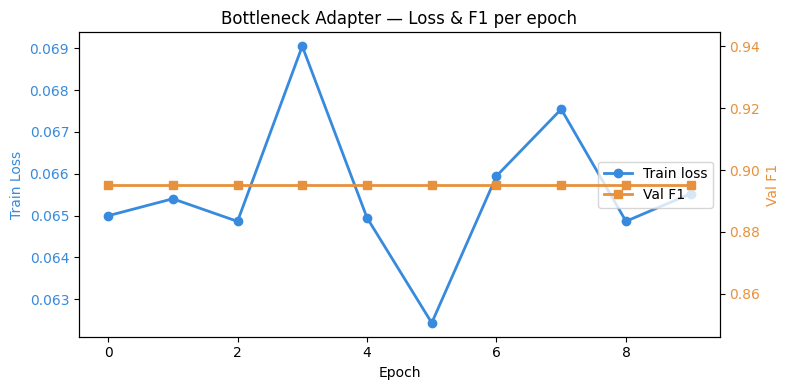

In [18]:
fig, ax1 = plt.subplots(figsize=(8, 4))

color_loss = "#378ADD"
color_f1   = "#E8913C"

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss", color=color_loss)
ax1.plot(train_losses, marker="o", color=color_loss, linewidth=2, label="Train loss")
ax1.tick_params(axis="y", labelcolor=color_loss)

ax2 = ax1.twinx()
ax2.set_ylabel("Val F1", color=color_f1)
f1_vals = [r["f1"] for r in eval_results]
ax2.plot(f1_vals, marker="s", color=color_f1, linewidth=2, label="Val F1")
ax2.tick_params(axis="y", labelcolor=color_f1)

# gộp legend từ cả 2 axes
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="center right")

plt.title("Bottleneck Adapter — Loss & F1 per epoch")
fig.tight_layout()
plt.savefig(os.path.join(output_dir, "adapter_curve.png"), dpi=120)
plt.show()


## Lưu kết quả vào biến toàn cục để so sánh sau

In [19]:
import json

adapter_summary = {
    "method"          : "Bottleneck Adapter",
    "model_name"      : model_name_or_path,
    "adapter_path"    : save_path,
    "adapter_config"  : "Pfeiffer, reduction_factor=16, bottleneck_dim=48",
    "trainable_params": trainable_params,
    "trainable_pct"   : adapter_param_pct,
    "best_val_f1"     : adapter_best_f1,
    "best_val_acc"    : adapter_best_acc,
    "test_f1"         : adapter_test_result["f1"],
    "test_acc"        : adapter_test_result["accuracy"],
    "training_time_s" : adapter_training_time,
    "peak_mem_gb"     : adapter_peak_mem,
}

summary_path = os.path.join(output_dir, "adapter_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(adapter_summary, f, ensure_ascii=False, indent=2)

print(adapter_summary)
print("Saved summary to:", summary_path)


{'method': 'Bottleneck Adapter', 'model_name': 'bert-base-uncased', 'adapter_path': '/kaggle/working/peft_outputs/bottleneck_adapter', 'adapter_config': 'Pfeiffer, reduction_factor=16, bottleneck_dim=48', 'trainable_params': 2109308, 'trainable_pct': 1.8902040860657296, 'best_val_f1': 0.8953279824456505, 'best_val_acc': 0.8953333333333333, 'test_f1': 0.9066397711748635, 'test_acc': 0.9066666666666666, 'training_time_s': 4820.9986255168915, 'peak_mem_gb': 2.454847488}
Saved summary to: /kaggle/working/peft_outputs/adapter_summary.json
